In [11]:
%load_ext autoreload
%autoreload 2
from helpers import *
from SINDyModel import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
def generate_noise_level_vs_dt_matrix(rhs, x0, t_span, noise_levels, dts):
    data = []

    for dt in dts:
        print(f"dt: {dt}")

        for noise_level in tqdm(noise_levels):
            data_entry = {}
            data_entry["dt"] = dt
            data_entry["noise_level"] = noise_level

            # generate evaluation time points
            t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
            data_entry["t_eval"] = t_eval

            # generate training data
            x_train = generate_training_data(rhs, x0, t_eval)
            # data_entry["x_train"] = x_train

            # generate true derivative for the trajectory
            x_dot_true = generate_true_derivative(lotka_volterra_rhs, x_train)
            data_entry["x_dot_true"] = x_dot_true

            # generate noisy data
            x_train_noisy = add_noise_to_data(x_train, noise_level)
            data_entry["x_train_noisy"] = x_train_noisy

            # generate different derivative approximations using the noisy data
            x_dot_finite_difference = dxdt(x_train_noisy, t_eval, kind="finite_difference", k=1)
            data_entry["x_dot_finite_difference"] = x_dot_finite_difference

            x_dot_savitzky_golay = dxdt(x_train_noisy, t_eval, kind="savitzky_golay", left=.5, right=.5, order=3)
            data_entry['x_dot_savitzky_golay'] = x_dot_savitzky_golay

            # x_dot_spline = dxdt(x_train_noisy, t_eval,  kind="spline", s=1e-2)
            # data_entry['x_dot_spline'] = x_dot_spline
            
            # store the data entry
            data.append(data_entry)
        
    return data


lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

noise_levels = np.logspace(-4, 0, 10).tolist()
dts = np.logspace(-2, 0, 10).tolist()

data = generate_noise_level_vs_dt_matrix(
    rhs=lotka_volterra_rhs,
    x0=(10, 5),
    t_span=(0, 50),
    noise_levels=noise_levels,
    dts=dts
)


dt: 0.01


100%|██████████| 10/10 [03:31<00:00, 21.18s/it]


dt: 0.016681005372000592


 50%|█████     | 5/10 [00:31<00:43,  8.63s/it]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\interpolate\_fitpack_py.py:295: RuntimeWarning: The maximal number of iterations (20) allowed for finding smoothing
spline with fp=s has been reached. Probable cause: s too small.
(abs(fp-s)/s>0.001)
  res = _impl.splrep(x, y, w, xb, xe, k, task, s, t, full_output, per, quiet)
100%|██████████| 10/10 [01:49<00:00, 10.93s/it]


dt: 0.027825594022071243


...

100%|██████████| 10/10 [00:01<00:00,  8.73it/s]


dt: 0.5994842503189409


100%|██████████| 10/10 [00:00<00:00, 11.79it/s]


dt: 1.0


100%|██████████| 10/10 [00:00<00:00, 18.18it/s]


In [25]:
# make a matrix of the relative squared errors

def relative_squared_error_matrix(deriv_kind):
    relative_squared_error_mtx = np.zeros((len(noise_levels), len(dts)))

    for data_entry in data:
        x_dot_true = data_entry["x_dot_true"]
        x_dot_finite_difference = data_entry["x_dot_" + deriv_kind]

        # compute the relative squared error
        rse = relative_squared_error(x_dot_true, x_dot_finite_difference)
        
        # store the relative squared error in the matrix
        dt_idx = dts.index(data_entry["dt"])
        noise_level_idx = noise_levels.index(data_entry["noise_level"])
        relative_squared_error_mtx[noise_level_idx, dt_idx] = rse
    
    return relative_squared_error_mtx

relative_squared_error_mtx_finite_difference = relative_squared_error_matrix("finite_difference")
relative_squared_error_mtx_savitzky_golay = relative_squared_error_matrix("savitzky_golay")
relative_squared_error_mtx_spline = relative_squared_error_matrix("spline")

[Text(0.5, 25.649999999999984, 'dt'),
 Text(59.64999999999999, 0.5, 'noise level'),
 Text(0.5, 1.0, 'Relative Squared Error for Spline')]

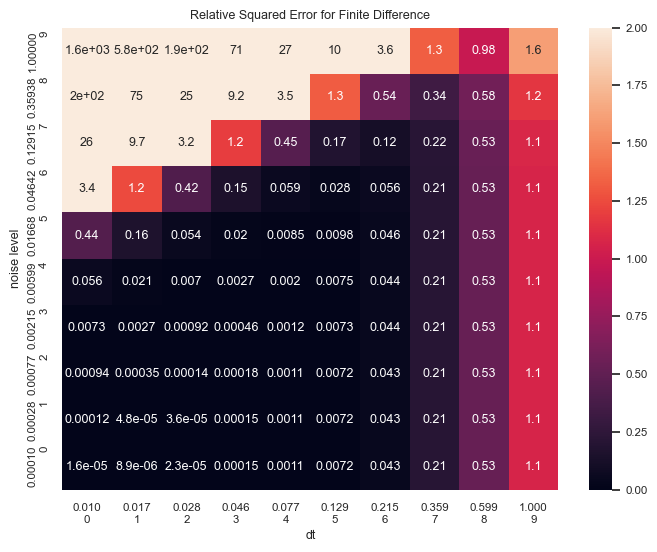

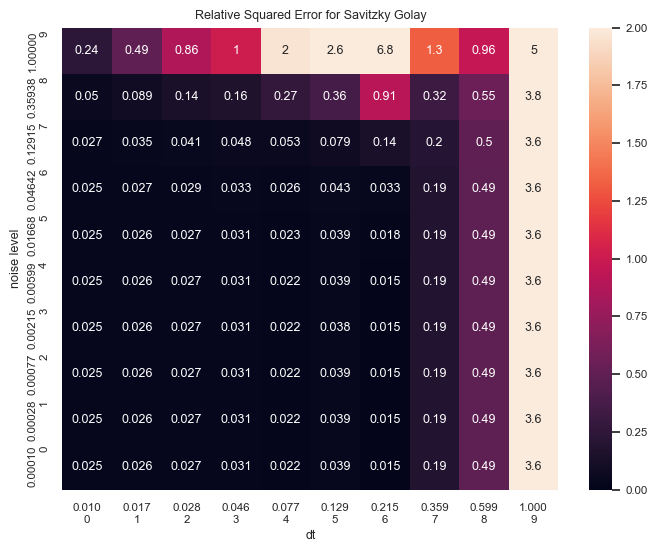

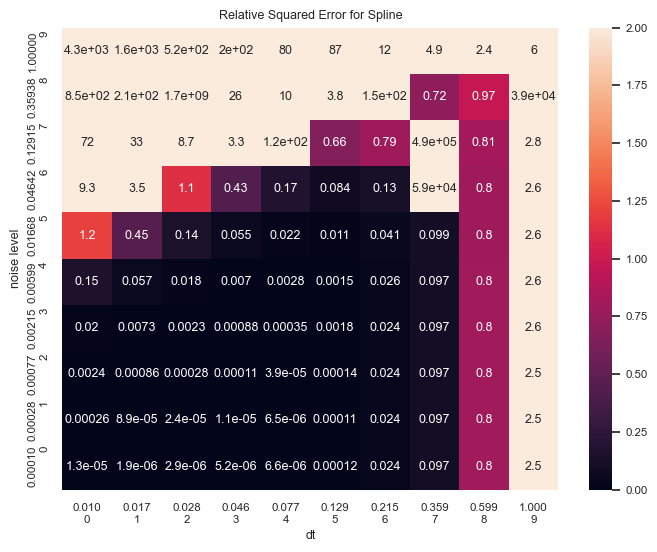

In [43]:
import seaborn as sns

sns.set_theme(font_scale=0.75)

xticklabels = [f"{dt:.3f}\n{i}" for i, dt in enumerate(dts)]
yticklabels = [f"{noise_level:.5f}\n{i}" for i, noise_level in list(enumerate(noise_levels))[::-1]]

fig = plt.figure(figsize=(8, 6))
ax = sns.heatmap(relative_squared_error_mtx_finite_difference[::-1, :], annot=True, vmin=0, vmax=2,
                 xticklabels=xticklabels,
                 yticklabels=yticklabels)
ax.set(xlabel='dt', ylabel='noise level', title="Relative Squared Error for Finite Difference")

fig = plt.figure(figsize=(8, 6))
ax = sns.heatmap(relative_squared_error_mtx_savitzky_golay[::-1, :], annot=True, vmin=0, vmax=2,
                 xticklabels=xticklabels,
                 yticklabels=yticklabels)
ax.set(xlabel='dt', ylabel='noise level', title="Relative Squared Error for Savitzky Golay")

fig = plt.figure(figsize=(8, 6))
ax = sns.heatmap(relative_squared_error_mtx_spline[::-1, :], annot=True, vmin=0, vmax=2,
                 xticklabels=xticklabels,
                 yticklabels=yticklabels)
ax.set(xlabel='dt', ylabel='noise level', title="Relative Squared Error for Spline")

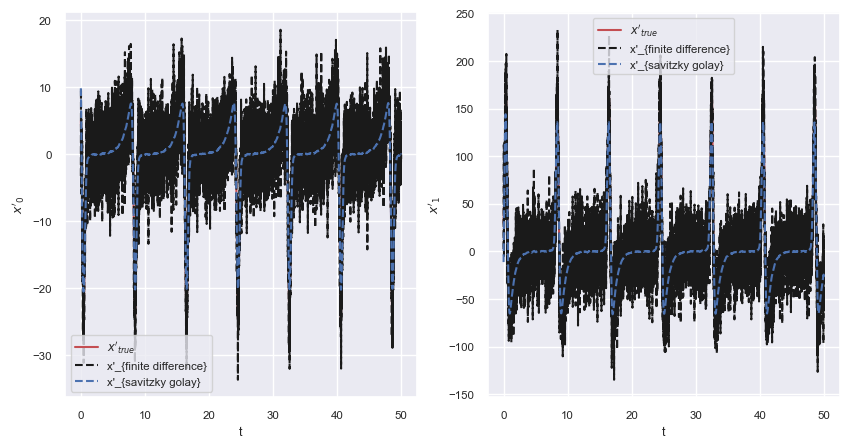

In [44]:
# set the indices of the data entry you'd like to explore
dt_idx = 0
noise_level_idx = 5

# find the data entry with the specified dt and noise level
data_entry = None
for de in data:
    if de["dt"] == dts[dt_idx] and de["noise_level"] == noise_levels[noise_level_idx]:
        data_entry = de

# extract the relevant data from the data entry
t_eval = data_entry['t_eval']
x_dot_true = data_entry['x_dot_true']
x_dot_finite_difference = data_entry['x_dot_finite_difference']
x_dot_savitzky_golay = data_entry['x_dot_savitzky_golay']
x_dot_spline = data_entry['x_dot_spline']

n_state_vars = x_dot_true.shape[0]

# plot the training data and model prediction
fig, axs = plt.subplots(1, n_state_vars, figsize=(10, 5))

for sv in range(n_state_vars):
    axs[sv].plot(t_eval, x_dot_true[sv], "r", label="$x'_{true}$")
    axs[sv].plot(t_eval, x_dot_finite_difference[sv], "k--", label="x'_{finite difference}")
    axs[sv].plot(t_eval, x_dot_savitzky_golay[sv], "b--", label="x'_{savitzky golay}")
    # axs[sv].plot(t_eval, x_dot_spline[sv], "g--", label="x'_{spline}")

    # set labels
    axs[sv].set_xlabel("t")
    axs[sv].set_ylabel(f"$x'_{sv}$")
    axs[sv].legend()